# Assignment 1: Housing Price Prediction

IE500618 — Group members: Magnus Grande, Ida Soldal

Workflow: Explore and understand data -> Split data -> Preprocess -> Select/engineer features -> Train models -> Evaluate and interpret

Dataset: `AmesHousing.csv`. Target: `SalePrice`.
Reference: `Ames_Housing_Understanding_the_Dataset.pdf` for column meanings/codes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv('AmesHousing.csv')

## Step 1 - Explore and understand the data

Use appropriate descriptive statistics and visualizations to investigate:
- the available variables and their data types;
- the distribution of SalePrice;
- missing values;
- unusual values or patterns; and
- relationships that may be useful for predicting house prices.

Choose analyses and visualizations that help you understand the data and support later decisions. Do not create plots simply for the sake of visualization. Use the dataset guide when terminology is unclear.

In [3]:
# 1 - The available variables and their data types

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")  # sanity check row/col count
print(df.dtypes.value_counts())  # how many columns per dtype
print(sorted(df['MS SubClass'].unique()))  # check: is this "numeric" col actually a code?

Shape: 2930 rows, 82 columns
str        43
int64      28
float64    11
Name: count, dtype: int64
[np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(150), np.int64(160), np.int64(180), np.int64(190)]


In [4]:
# 1 (cont.) - A look at the actual values

df.head()  # peek at actual values per column

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


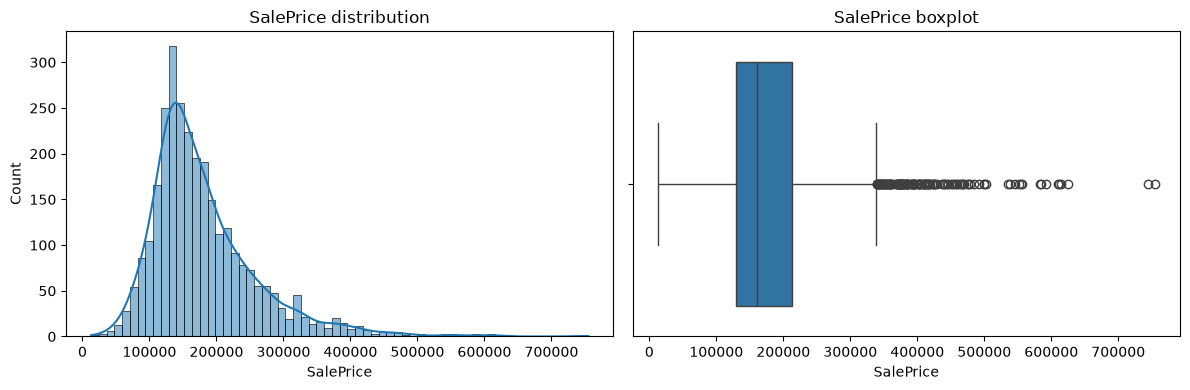

In [5]:
# 2 - The distribution of SalePrice

print(df['SalePrice'].describe())  # summary stats: mean, median, min/max, quartiles

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])  # shape of the distribution
axes[0].set_title('SalePrice distribution')
sns.boxplot(x=df['SalePrice'], ax=axes[1])  # spot outliers
axes[1].set_title('SalePrice boxplot')
plt.tight_layout()
plt.show()

# Right-skewed with a long tail

In [6]:
# 3 - Missing values

missing = df.isna().sum().sort_values(ascending=False)  # count missing per column
missing_pct = (missing / len(df) * 100).round(1)  # convert to percentage
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table[missing_table['missing_count'] > 0]  # only show columns with any missing values

,missing_count,missing_pct
Pool QC,2917,99.6
Misc Feature,2824,96.4
Alley,2732,93.2
Fence,2358,80.5
Mas Vnr Type,1775,60.6
Fireplace Qu,1422,48.5
Lot Frontage,490,16.7
Garage Cond,159,5.4
Garage Finish,159,5.4
Garage Yr Blt,159,5.4


In [7]:
# 4 - Unusual values or patterns

df.nlargest(5, 'Gr Liv Area')[['Gr Liv Area', 'SalePrice', 'Sale Condition', 'Overall Qual']]  # biggest houses by living area

,Gr Liv Area,SalePrice,Sale Condition,Overall Qual
1498,5642,160000,Partial,10
2180,5095,183850,Partial,10
2181,4676,184750,Partial,10
1760,4476,745000,Abnorml,10
1767,4316,755000,Normal,10


SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


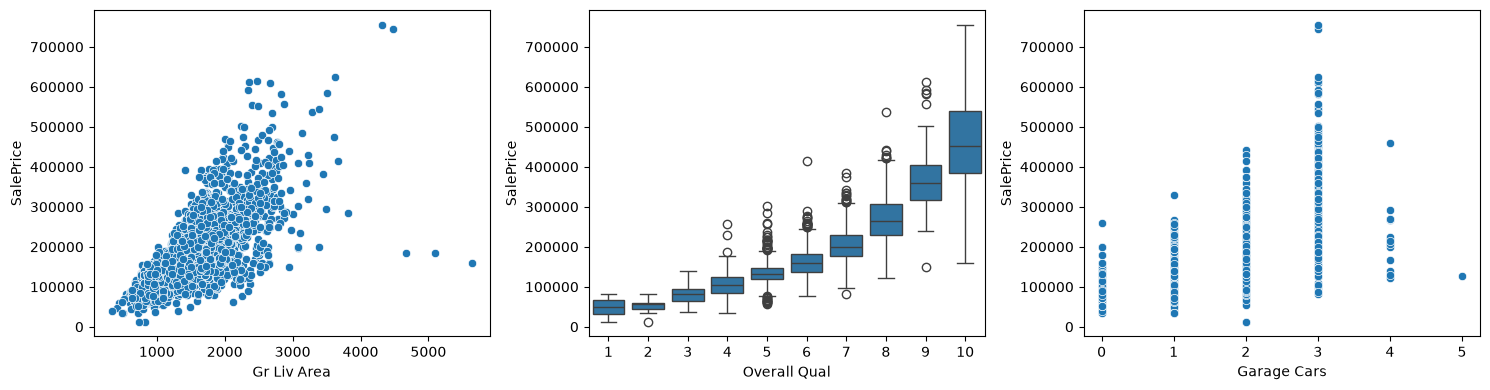

In [8]:
# 5 - Relationships that may be useful for predicting house prices

corr_with_price = df.select_dtypes(include=np.number).corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)  # correlation of each numeric col with price
print(corr_with_price.head(11))  # top 10 most correlated features

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice', ax=axes[0])  # size vs price
sns.boxplot(data=df, x='Overall Qual', y='SalePrice', ax=axes[1])  # quality rating vs price
sns.scatterplot(data=df, x='Garage Cars', y='SalePrice', ax=axes[2])  # garage size vs price
plt.tight_layout()
plt.show()

## Step 2 - Create training and test data

Split the dataset into training and test sets. Use the training data to develop your solution and keep the test data separate for final evaluation on unseen data.

In [9]:
# Split the dataset into training and test sets
X = df.drop(columns=['SalePrice'])  # features = everything except the target
y = df['SalePrice']  # target = the price we want to predict

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80/20 split, reproducible via random_state

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")  # confirm split sizes

# Test set is set aside now and left untouched until final evaluation, so preprocessing/feature/model choices can't leak information from it

Train: 2344 rows, Test: 586 rows


## Step 3 - Prepare the data

Using the training data, decide how to prepare the data for the models. This may include:
- handling missing values based on what they represent in the Understanding the Dataset guide;
- encoding categorical variables;
- scaling or transforming numerical variables where appropriate; and
- removing variables when there is a clear reason to do so.

**Important:** Preprocessing should be learned from the training data and then applied in the same way to the test data. Do not learn preprocessing from the complete dataset, and do not fit preprocessing separately on the test data.

In [10]:
# Remove the outlier rows flagged in Step 1, from training data only (test set is left untouched)
outlier_mask = (X_train['Gr Liv Area'] > 4000) & (X_train['Sale Condition'] == 'Partial')  # matches the Step 1 outliers: huge size, low price, incomplete/"Partial" sale
n_outliers = outlier_mask.sum()  # how many rows match

X_train = X_train[~outlier_mask]  # drop them from features
y_train = y_train[~outlier_mask]  # drop matching rows from target, keeping index alignment

print(f"Removed {n_outliers} outlier rows from training data. New train size: {X_train.shape[0]}")  # confirm removal

# Only removed from training data -- test set stays untouched so evaluation still reflects realistic unseen data

Removed 2 outlier rows from training data. New train size: 2342


In [11]:
# 4 - Removing variables when there is a clear reason to do so

id_cols = ['Order', 'PID']  # row identifiers, carry no predictive information
X_train = X_train.drop(columns=id_cols)  # drop from train
X_test = X_test.drop(columns=id_cols)  # drop from test

X_train = X_train.drop(columns=['Garage Yr Blt'])  # redundant with Year Built, and awkward to fill for "no garage" rows
X_test = X_test.drop(columns=['Garage Yr Blt'])  # same drop applied to test

print(f"Columns remaining: {X_train.shape[1]}")  # confirm drop

# Done first (before filling missing values) so Garage Yr Blt's many "no garage" gaps never need to be imputed at all

Columns remaining: 78


In [12]:
# 1 - Handling missing values based on what they represent in the Understanding the Dataset guide

cat_none_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Garage Finish', 'Garage Type', 'Bsmt Exposure', 'BsmtFin Type 2', 'BsmtFin Type 1', 'Bsmt Cond', 'Bsmt Qual']  # missing = feature genuinely absent
num_zero_cols = ['Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Half Bath', 'Bsmt Full Bath', 'Garage Area', 'Garage Cars']  # missing = no basement/garage/veneer, so 0 is correct
num_median_cols = ['Lot Frontage']  # missing = real measurement that wasn't recorded

for col in cat_none_cols:
    X_train[col] = X_train[col].fillna('None')  # explicit "no feature" category
    X_test[col] = X_test[col].fillna('None')  # same rule applied to test

for col in num_zero_cols:
    X_train[col] = X_train[col].fillna(0)  # 0 = feature doesn't exist
    X_test[col] = X_test[col].fillna(0)  # same rule applied to test

for col in num_median_cols:
    median_val = X_train[col].median()  # learn median from training data only
    X_train[col] = X_train[col].fillna(median_val)  # fill training gaps
    X_test[col] = X_test[col].fillna(median_val)  # apply the SAME value to test, don't recompute

electrical_mode = X_train['Electrical'].mode()[0]  # most frequent category, learned from training data only
X_train['Electrical'] = X_train['Electrical'].fillna(electrical_mode)  # train has no gaps here, but keeps the fill value train-derived
X_test['Electrical'] = X_test['Electrical'].fillna(electrical_mode)  # test's missing row gets the train-derived mode

print("Remaining missing values -- train:", X_train.isna().sum().sum(), "test:", X_test.isna().sum().sum())  # confirm 0 in both

# Categorical/most numeric gaps mean "no such feature" (fill 'None'/0); Lot Frontage and Electrical are real unrecorded values, so they get a statistic learned from training data only

Remaining missing values -- train: 0 test: 0


In [13]:
# 2 - Encoding categorical variables

categorical_cols = list(X_train.select_dtypes(exclude=np.number).columns) + ['MS SubClass']  # text columns + the numeric-looking house-type code flagged in Step 1
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]  # everything else, kept aside for scaling next

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # ignore categories only seen in test instead of crashing
encoder.fit(X_train[categorical_cols])  # learn categories from training data only

train_encoded = pd.DataFrame(encoder.transform(X_train[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index)  # apply to train
test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols), index=X_test.index)  # apply the SAME fitted encoder to test

X_train = pd.concat([X_train[numeric_cols], train_encoded], axis=1)  # swap raw categories for encoded columns
X_test = pd.concat([X_test[numeric_cols], test_encoded], axis=1)  # same swap for test

print(f"Columns after encoding: {X_train.shape[1]}")  # confirm new column count

# Encoder is fit on training categories only; a category seen only in test is safely ignored (all-zero row) instead of breaking the pipeline

Columns after encoding: 327


In [14]:
# 3 - Scaling or transforming numerical variables where appropriate

scaler = StandardScaler()  # standardize to mean 0, std 1
scaler.fit(X_train[numeric_cols])  # learn mean/std from training data only

X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])  # apply to train
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])  # apply the SAME scaler to test

print(X_train[numeric_cols].describe().loc[['mean', 'std']].round(2))  # confirm ~0 mean, ~1 std on train

# Only LinearRegression needs scaling (tree-based models are scale-invariant), but scaling once keeps preprocessing identical across all three Step 5 models

      Lot Frontage  Lot Area  Overall Qual  Overall Cond  Year Built  \
mean           0.0       0.0          -0.0          -0.0         0.0   
std            1.0       1.0           1.0           1.0         1.0   

      Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  \
mean             0.0           0.0           0.0          -0.0          0.0   
std              1.0           1.0           1.0           1.0          1.0   

      Total Bsmt SF  1st Flr SF  2nd Flr SF  Low Qual Fin SF  Gr Liv Area  \
mean            0.0         0.0         0.0              0.0          0.0   
std             1.0         1.0         1.0              1.0          1.0   

      Bsmt Full Bath  Bsmt Half Bath  Full Bath  Half Bath  Bedroom AbvGr  \
mean             0.0             0.0        0.0        0.0            0.0   
std              1.0             1.0        1.0        1.0            1.0   

      Kitchen AbvGr  TotRms AbvGrd  Fireplaces  Garage Cars  Garage Area  \
mean 

## Step 4 - Select and engineer features

Decide which features to use for prediction. Use evidence from the training data, such as visualizations, descriptive statistics, correlation analysis and your understanding of the variables. You may keep useful features, remove features that are not useful or appropriate, and create new meaningful features. You do not have to use every column.

In [15]:
# Select and engineer features, using correlation evidence from the training data

house_age_train = df.loc[X_train.index, 'Yr Sold'] - df.loc[X_train.index, 'Year Built']  # new feature: how old the house was at sale time
house_age_test = df.loc[X_test.index, 'Yr Sold'] - df.loc[X_test.index, 'Year Built']  # same formula applied to test rows

total_sf_train = df.loc[X_train.index, '1st Flr SF'] + df.loc[X_train.index, '2nd Flr SF'] + df.loc[X_train.index, 'Total Bsmt SF'].fillna(0)  # new feature: combined living + basement area (no basement = 0)
total_sf_test = df.loc[X_test.index, '1st Flr SF'] + df.loc[X_test.index, '2nd Flr SF'] + df.loc[X_test.index, 'Total Bsmt SF'].fillna(0)  # same formula applied to test rows

engineered_scaler = StandardScaler()  # scale the new features the same way as the rest of Step 3
engineered_scaler.fit(np.column_stack([house_age_train, total_sf_train]))  # learn mean/std from training data only

X_train[['House Age', 'Total SF']] = engineered_scaler.transform(np.column_stack([house_age_train, total_sf_train]))  # add scaled new features to train
X_test[['House Age', 'Total SF']] = engineered_scaler.transform(np.column_stack([house_age_test, total_sf_test]))  # apply the SAME scaler to test

corr_with_target = X_train.apply(lambda col: np.corrcoef(col, y_train)[0, 1])  # correlation of every current feature with SalePrice
print(corr_with_target[['House Age', 'Total SF', 'Gr Liv Area', 'Total Bsmt SF']].round(3))  # check the new features are informative

weak_features = corr_with_target[corr_with_target.abs() < 0.05].index  # features with almost no linear relationship to SalePrice, mostly rare one-hot categories
X_train = X_train.drop(columns=weak_features)  # remove them from train
X_test = X_test.drop(columns=weak_features)  # same removal applied to test

print(f"Removed {len(weak_features)} weak features. Final feature count: {X_train.shape[1]}")  # confirm result

# House Age and Total SF summarize known price drivers (recency, size) into single strong signals (corr 0.55 and 0.82), while dropping near-zero-correlation one-hot columns reduces noise without discarding useful information

House Age       -0.547
Total SF         0.819
Gr Liv Area      0.717
Total Bsmt SF    0.645
dtype: float64
Removed 119 weak features. Final feature count: 210


## Step 5 - Train the models

Using the same prepared features, train these three regression models:
- LinearRegression
- DecisionTreeRegressor
- RandomForestRegressor

Treat them as on-the-shelf models. Hyperparameter tuning is not required. Use the same prepared features for all three models so that their test performance can be compared fairly.

In [16]:
# 1 - LinearRegression

lin_reg = LinearRegression()  # plain linear regression, no regularization or tuning
lin_reg.fit(X_train, y_train)  # fit on the same prepared training features as the other models

print("LinearRegression trained")  # confirm fit completed

# Serves as the baseline: a simple linear model to compare against the two tree-based models below

LinearRegression trained


In [17]:
# 2 - DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)  # default settings, reproducible via random_state
tree_reg.fit(X_train, y_train)  # fit on the same prepared training features

print("DecisionTreeRegressor trained")  # confirm fit completed

# Can capture non-linear relationships LinearRegression can't, but a single tree is prone to overfitting

DecisionTreeRegressor trained


In [18]:
# 3 - RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)  # default settings, reproducible via random_state
forest_reg.fit(X_train, y_train)  # fit on the same prepared training features

print("RandomForestRegressor trained")  # confirm fit completed

# Averaging many trees typically reduces the overfitting risk of a single DecisionTreeRegressor

RandomForestRegressor trained


## Step 6 - Evaluate and interpret the results

Evaluate all three models on the test data using:
- **RMSE** (Root Mean Squared Error): measures the size of prediction errors in the same units as SalePrice. Lower is better.
- **R²** (R-squared): compares the model predictions with a simple mean-prediction baseline. Higher is generally better; R² = 1 is perfect, R² = 0 is no better than predicting the mean, and R² can be negative. Do not describe R² as percentage accuracy.

| Model | Test RMSE | Test R² |
|---|---|---|
| Linear Regression | | |
| Decision Tree Regression | | |
| Random Forest Regression | | |

In [ ]:
# Evaluate all three models on the test data using RMSE and R²

models = {'Linear Regression': lin_reg, 'Decision Tree Regression': tree_reg, 'Random Forest Regression': forest_reg}  # map readable names to the fitted models

results = []  # collect one row per model
for name, model in models.items():
    preds = model.predict(X_test)  # predict on the held-out test set, unseen during training
    rmse = mean_squared_error(y_test, preds) ** 0.5  # error in the same units as SalePrice
    r2 = r2_score(y_test, preds)  # compares predictions against a mean-prediction baseline
    results.append({'Model': name, 'Test RMSE': rmse, 'Test R²': r2})  # store this model's row

results_df = pd.DataFrame(results)  # build a comparison table
print(results_df.round(3))  # display results for all three models side by side

# Random Forest performs best (lowest RMSE, highest R²); the single Decision Tree overfits the training data and generalizes worst

                      Model  Test RMSE  Test R²
0         Linear Regression  28637.055    0.898
1  Decision Tree Regression  45052.532    0.747
2  Random Forest Regression  27760.404    0.904
